In [159]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph  , START , END
from dotenv import load_dotenv
from typing import TypedDict , Literal
from math import sqrt
from pydantic import BaseModel , Field
load_dotenv()

True

In [160]:
model = ChatGoogleGenerativeAI(model = 'gemini-3.5-flash')

In [161]:
class LLmstate(TypedDict):
    review: str
    sentiment: Literal["positive" , "negative"]
    response: str

    issue_type: Literal["billing", "tech", "delivery", "other"]
    tone: Literal["angry", "frustrated", "calm", "neutral"]
    urgency: Literal["low", "medium", "high"]

In [162]:
class sentimentstruct(BaseModel):
    sentiment:  Literal["positive" , "negative"] = Field(description="Sentimkent of the reviewonly in positive and negative")

In [163]:
class diagnostic_struct(BaseModel):
    issue_type: Literal["billing", "tech", "delivery", "other"] = Field(description = "Tell the issue according to the review and it should be in billing, tech, delivery, other ")
    tone: Literal["angry", "frustrated", "calm", "neutral"] = Field(description = 'Tell the tone according to the review and it should be in "angry", "frustrated", "calm", "neutral" ')
    urgency: Literal["low", "medium", "high"] = Field(description = 'Tell the urgency according to the review and it should be in "low", "medium", "high" ')

In [164]:
senti_llm = model.with_structured_output(sentimentstruct)

In [165]:
diag_llm = model.with_structured_output(diagnostic_struct)

In [166]:
graph = StateGraph(LLmstate)

In [167]:
def get_sentiment(state: LLmstate) -> LLmstate:
    review = state["review"]

    prompt = f"Tell the issue according to the review that is {review} and it should be in billing, tech, delivery, other "
    result = senti_llm.invoke(prompt)
    state["sentiment"] = result.sentiment

    return state

In [168]:
def conditional(state: LLmstate) -> Literal["positive_response" , "diagnosis"]:
    if state["sentiment"] == "positive":
        return "positive_response"
    elif state["sentiment"] == "negative":
        return "diagnosis"

In [ ]:
def positive_response(state = LLmstate) -> LLmstate:
    review = state["review"]
    prompt = f"According to this review \n {review} \n response to the user"
    result = model.invoke(prompt)
    state["response"] = result.content

    return state

In [170]:
def diagnosis(state:LLmstate) -> LLmstate:
    review  = state["review"]
    prompt = f"this is a negative review {review} , diagnose it for issue_type , tone and urgency"
    result = diag_llm.invoke(prompt)
    state["issue_type"] = result.issue_type
    state["tone"] = result.tone
    state["urgency"] = result.urgency

    return state

In [ ]:
def negative_response(state: LLmstate) -> LLmstate:
    review = state["review"]
    issue_type = state["issue_type"]
    tone = state["tone"]
    urgency = state["urgency"]

    prompt = f"This is a negative review \n{review} \n. and i have also attached the issue tyoe = {issue_type} , tone = {tone} , urgency = {urgency} no give a response to user by using this data."

    result = model.invoke(prompt)
    state["response"] = result.content
    
    return state


[{'type': 'text', 'text': "Subject: Urgent: Assistance with your phone's keyboard issue\n\nHi there,\n\nI am incredibly sorry to hear how frustrated you are with your phone's keyboard. I completely understand how vital a functioning keyboard is for your daily work, and it is unacceptable that this is preventing you from using your phone. \n\nPlease rest assured that we are treating this issue with the **highest priority**. Based on your feedback, we have logged this as a **product defect**, and our technical team is ready to investigate this immediately.\n\nTo help us resolve this for you ASAP, could you please reply with a few quick details?\n1. **Your phone model** (e.g., iPhone 15, Samsung S23, etc.).\n2. **A brief description of the defect** (e.g., is the keyboard freezing, lagging, missing keys, or not popping up at all?).\n\n**In the meantime, here is a quick step you can try right now that may temporarily resolve the issue:**\n* **For Android:** Go to Settings > Apps > [Your Key

In [172]:
graph.add_node("get_sentiment",get_sentiment)
graph.add_node("negative_response",negative_response)
graph.add_node("diagnosis",diagnosis)
graph.add_node("positive_response",positive_response)


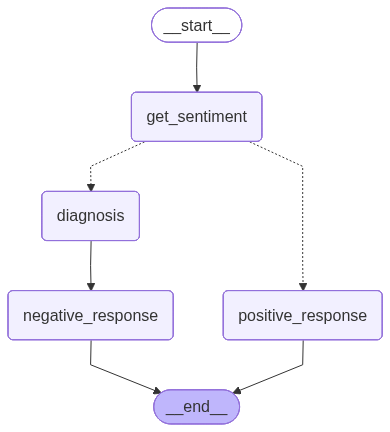

In [173]:
graph.add_edge(START , "get_sentiment")
graph.add_conditional_edges("get_sentiment" , conditional)
graph.add_edge("diagnosis" , "negative_response")
graph.add_edge("negative_response" , END)
graph.add_edge("positive_response" , END)


workflow = graph.compile()



workflow




In [174]:
initial_state = {"review":"This phone has a terrible keyboard. i cant work with this at all. i am so frustrated. fix this ASAP"}
final_state = workflow.invoke(initial_state)

In [175]:
final_state

{'review': 'This phone has a terrible keyboard. i cant work with this at all. i am so frustrated. fix this ASAP',
 'sentiment': 'negative',
 'response': [{'type': 'text',
   'text': 'Subject: Assistance with your keyboard issue - Urgent Support\n\nHello,\n\nI am incredibly sorry to hear about the extreme frustration this keyboard issue is causing you. I completely understand that you need your phone to work reliably for your daily tasks, and we want to help you get this resolved immediately. \n\nSince this is a technical issue, here are a few quick troubleshooting steps you can try right now to see if it resolves the problem:\n\n1. **Restart your phone:** A quick reboot can often clear temporary system glitches affecting the keyboard.\n2. **Clear the keyboard cache:** Go to **Settings** > **Apps** > select your keyboard app (e.g., Gboard, Samsung Keyboard, or default keyboard) > **Storage** > **Clear Cache**.\n3. **Check for updates:** Ensure both your phone’s operating system and your